<a href="https://colab.research.google.com/github/Tigason509/Projet_Bio_Informatique/blob/main/Projet_Bio_Informatique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
url="https://raw.githubusercontent.com/Tigason509/Projet_Bio_Informatique/refs/heads/main/data_raw/"
#Nous définissons une variable url pour ne pas à avoir a répéter la longue @ URL.
urls = {
    "co2":f"{url}/annual-co2-emissions-per-country.csv",
    "pib":f"{url}/gdp-per-capita-worldbank.csv",
    "energie" :f"{url}/primary-energy-consumption.csv",
    "population":f"{url}/population.csv",
    "pib_maddison":f"{url}/gdp-per-capita-maddison-project-database.csv",
    "terres_arables":f"{url}/total-agricultural-area-over-the-long-term.csv",
}

In [44]:

try:
    co2 = pd.read_csv(urls["co2"])
    energie = pd.read_csv(urls["energie"])
    pib = pd.read_csv(urls["pib"])
    population = pd.read_csv(urls["population"])
    pib_maddison = pd.read_csv(urls["pib_maddison"])
    terres_arables = pd.read_csv(urls["terres_arables"])
    print("Données chargées")
except Exception as e:
    print(f"Erreur lors du chargement : {e}")
display(terres_arables.head())


Données chargées


,entity,code,year,agriculture_c
0,Afghanistan,AFG,-10000,0.000
1,Afghanistan,AFG,-9000,0.000
2,Afghanistan,AFG,-8000,0.000
3,Afghanistan,AFG,-7000,0.000
4,Afghanistan,AFG,-6000,39494.934


In [46]:
for c in ["USA","GBR","FRA","DEU","JPN","RUS","CHN"]:
    print(c, c in co2["Code"].dropna().unique())


USA True
GBR True
FRA True
DEU True
JPN True
RUS True
CHN True


In [5]:
# Liste des 7 pays que nous voulons analyser (codes ISO3)
TARGET = ["USA", "GBR", "FRA", "DEU", "JPN", "RUS", "CHN"]

# Filtrer le dataset pour garder seulement ces pays
co2_7 = co2[co2["Code"].isin(TARGET)].copy()

# Garder uniquement les colonnes utiles pour notre analyse
# On renomme les colonnes pour avoir des noms simples et propres
co2_7 = co2_7[["Code", "Year", "Annual CO₂ emissions"]].rename(columns={
    "Code": "iso3",                 # Code pays (USA, FRA, etc.)
    "Year": "year",                 # Année
    "Annual CO₂ emissions": "co2_total"  # Emissions totales de CO2
})

# Vérifier la période couverte et les pays présents
print("Année minimum :", co2_7["year"].min())
print("Année maximum :", co2_7["year"].max())
print("Pays présents :", co2_7["iso3"].unique())


Année minimum : 1750
Année maximum : 2024
Pays présents : ['CHN' 'FRA' 'DEU' 'JPN' 'RUS' 'GBR' 'USA']


In [6]:
# Garder seulement les années après 1900
co2_7 = co2_7[(co2_7["year"] >= 1900)]

# Vérification après filtrage
print("Nouvelle année min :", co2_7["year"].min())
print("Nouvelle année max :", co2_7["year"].max())
print("Nombre total de lignes :", co2_7.shape[0])
co2_7.head()

Nouvelle année min : 1900
Nouvelle année max : 2024
Nombre total de lignes : 868


,iso3,year,co2_total
5654,CHN,1907,19893872.0
5655,CHN,1908,22735854.0
5656,CHN,1909,24251576.0
5657,CHN,1910,25009438.0
5658,CHN,1911,24630506.0


Téléchargement des fichiers pour la 1ère fois

In [7]:
#Lien drive pour avoir accès alternatif aux autres fichiers
Lien ="https://drive.google.com/drive/folders/1jSjOc7BZewmwWIIqNbpeGdV6uDlwvbjk?usp=drive_link"
fichiers = [
    "annual-co2-emissions-per-country.csv",
    "gdp-per-capita-worldbank.csv",
    "gdp-per-capita-maddison-project-database.csv",
    "primary-energy-consumption.csv",
    "population.csv"
]


# Étape 1 — Préparation des données CO₂

## Objectif
Construire un dataset propre des émissions annuelles de CO₂ pour les 7 pays étudiés :

- USA
- UK (GBR)
- France (FRA)
- Allemagne (DEU)
- Japon (JPN)
- Russie (RUS)
- Chine (CHN)

## Dataset utilisé
- Fichier : `annual-co2-emissions-per-country.csv`
- Source : Our World in Data (basé sur Global Carbon Project)
- Période initiale : 1750–2024

## Méthodologie
1. Charger le dataset depuis le dossier partagé.
2. Filtrer uniquement les 7 pays d’étude.
3. Garder uniquement les colonnes utiles :
   - `iso3` (code pays)
   - `year`
   - `co2_total`
4. Limiter la période à partir de 1900.
5. Sauvegarder le fichier nettoyé dans `data_clean/`.

## Résultat attendu
Un fichier propre au format **panel pays–année** :
- `iso3`
- `year`
- `co2_total`

Ce fichier servira de base pour les analyses ultérieures.


In [8]:
# Voir les premières lignes
co2.head()


,Entity,Code,Year,Annual CO₂ emissions
0,Afghanistan,AFG,1949,14656.0
1,Afghanistan,AFG,1950,84272.0
2,Afghanistan,AFG,1951,91600.0
3,Afghanistan,AFG,1952,91600.0
4,Afghanistan,AFG,1953,106256.0


In [9]:
co2.columns

Index(['Entity', 'Code', 'Year', 'Annual CO₂ emissions'], dtype='object')

In [10]:
#sorted(co2["Code"].dropna().unique())

In [11]:
for c in ["USA","GBR","FRA","DEU","JPN","RUS","CHN"]:
    print(c, c in co2["Code"].dropna().unique())

USA True
GBR True
FRA True
DEU True
JPN True
RUS True
CHN True


In [12]:
# Liste des 7 pays que nous voulons analyser (codes ISO3)
TARGET = ["USA", "GBR", "FRA", "DEU", "JPN", "RUS", "CHN"]

# Filtrer le dataset pour garder seulement ces pays
co2_7 = co2[co2["Code"].isin(TARGET)].copy()

# Garder uniquement les colonnes utiles pour notre analyse
# On renomme les colonnes pour avoir des noms simples et propres
co2_7 = co2_7[["Code", "Year", "Annual CO₂ emissions"]].rename(columns={
    "Code": "iso3",                 # Code pays (USA, FRA, etc.)
    "Year": "year",                 # Année
    "Annual CO₂ emissions": "co2_total"  # Emissions totales de CO2
})

# Vérifier la période couverte et les pays présents
print("Année minimum :", co2_7["year"].min())
print("Année maximum :", co2_7["year"].max())
print("Pays présents :", co2_7["iso3"].unique())


Année minimum : 1750
Année maximum : 2024
Pays présents : ['CHN' 'FRA' 'DEU' 'JPN' 'RUS' 'GBR' 'USA']


In [13]:
# Garder seulement les années après 1900
co2_7 = co2_7[(co2_7["year"] >= 1900)]

# Vérification après filtrage
print("Nouvelle année min :", co2_7["year"].min())
print("Nouvelle année max :", co2_7["year"].max())
print("Nombre total de lignes :", co2_7.shape[0])
co2_7.head()


Nouvelle année min : 1900
Nouvelle année max : 2024
Nombre total de lignes : 868


,iso3,year,co2_total
5654,CHN,1907,19893872.0
5655,CHN,1908,22735854.0
5656,CHN,1909,24251576.0
5657,CHN,1910,25009438.0
5658,CHN,1911,24630506.0


In [14]:
co2_7.to_csv("co2_total_clean.csv",index=False)

## Étape 2 — PIB par habitant (World Bank)

**Objectif :** préparer un fichier propre `pays–année` pour le PIB par habitant, afin de le fusionner ensuite avec le CO₂.

### Dataset utilisé
- Fichier : `gdp-per-capita-worldbank.csv` (dans `data_raw/`)
- Source : World Bank via Our World in Data (format OWID)

### Ce qu’on va faire
1. Charger le CSV
2. Vérifier les colonnes et la période couverte
3. Filtrer les 7 pays : USA, GBR, FRA, DEU, JPN, RUS, CHN
4. Garder uniquement : `iso3`, `year`, `gdp_per_capita`
5. Sauvegarder le résultat dans `data_clean/`


In [15]:

# Afficher les premières lignes pour vérifier la structure
pib.head()



,Entity,Code,Year,GDP per capita,World region according to OWID
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


In [16]:
pib.columns

Index(['Entity', 'Code', 'Year', 'GDP per capita',
       'World region according to OWID'],
      dtype='object')

In [17]:
# Liste des 7 pays étudiés
TARGET = ["USA", "GBR", "FRA", "DEU", "JPN", "RUS", "CHN"]

# Filtrer uniquement ces pays
pib_7 = pib[pib["Code"].isin(TARGET)].copy()

# Garder uniquement les colonnes utiles et les renommer proprement
pib_7 = pib_7[["Code", "Year", "GDP per capita"]].rename(columns={
    "Code": "iso3",
    "Year": "year",
    "GDP per capita": "gdp_per_capita"
})

# Vérifier la période et les pays présents
print("Année min :", pib_7["year"].min())
print("Année max :", pib_7["year"].max())
print("Pays présents :", pib_7["iso3"].unique())


Année min : 1990
Année max : 2024
Pays présents : ['CHN' 'FRA' 'DEU' 'JPN' 'RUS' 'GBR' 'USA']


## Complément — PIB historique (Maddison Project)

Le dataset World Bank commence seulement en 1990.
Pour couvrir la période historique (1900–1989),
nous utilisons le dataset Maddison Project.

Objectif :
- Charger le dataset Maddison
- Filtrer les 7 pays étudiés
- Garder les colonnes utiles
- Fusionner plus tard avec le PIB World Bank


In [18]:
# Charger le dataset Maddison


# Afficher les premières lignes
pib_maddison.head()


,Entity,Code,Year,GDP per capita,GDP per capita (Annotations)
0,Afghanistan,AFG,1950,1156.0,NaN
1,Afghanistan,AFG,1951,1170.0,NaN
2,Afghanistan,AFG,1952,1189.0,NaN
3,Afghanistan,AFG,1953,1240.0,NaN
4,Afghanistan,AFG,1954,1245.0,NaN


In [19]:
pib_maddison.columns

Index(['Entity', 'Code', 'Year', 'GDP per capita',
       'GDP per capita (Annotations)'],
      dtype='object')

In [20]:
# Liste des 7 pays étudiés
TARGET = ["USA", "GBR", "FRA", "DEU", "JPN", "RUS", "CHN"]

# Filtrer uniquement ces pays
pib_maddison_7 = pib_maddison[pib_maddison["Code"].isin(TARGET)].copy()

# Garder uniquement les colonnes utiles et renommer
pib_maddison_7 = pib_maddison_7[["Code", "Year", "GDP per capita"]].rename(columns={
    "Code": "iso3",
    "Year": "year",
    "GDP per capita": "gdp_per_capita_maddison"
})

# Vérifier période + pays présents
print("Année min :", pib_maddison_7["year"].min())
print("Année max :", pib_maddison_7["year"].max())
print("Pays présents :", pib_maddison_7["iso3"].unique())


Année min : 1
Année max : 2022
Pays présents : ['CHN' 'FRA' 'DEU' 'JPN' 'RUS' 'GBR' 'USA']


## Fusion des données PIB (Maddison + World Bank)

Nous avons utilisé deux sources pour le PIB par habitant :

- Maddison Project → données historiques longues (1900–2022)
- World Bank → données officielles modernes (1990–2024)

Pourquoi fusionner ?

Le dataset World Bank commence seulement en 1990,
ce qui ne couvre pas les guerres mondiales.

Le dataset Maddison couvre la période historique,
mais pour les années récentes, la World Bank fournit
des données plus standardisées et actualisées.

Nous avons donc :

- Utilisé Maddison pour les années anciennes
- Utilisé World Bank lorsque disponible (priorité aux données récentes)

Cela permet d’obtenir une série continue 1900–2024
plus robuste et méthodologiquement solide.


In [21]:
# Fusionner les deux datasets sur iso3 + year
pib_combinee = pd.merge(
    pib_maddison_7,
    pib_7,
    on=["iso3", "year"],
    how="outer"
)

# Créer une colonne finale :
# Si la valeur World Bank existe, on la prend.
# Sinon, on prend Maddison.
pib_combinee["gdp_per_capita"] = pib_combinee["gdp_per_capita"].combine_first(
    pib_combinee["gdp_per_capita_maddison"]
)

# Garder seulement les colonnes finales utiles
les_pib_finals = pib_combinee[["iso3", "year", "gdp_per_capita"]]

# Garder période à partir de 1900
les_pib_finals = les_pib_finals[les_pib_finals["year"] >= 1900]

# Vérification
print("Année min :", les_pib_finals["year"].min())
print("Année max :", les_pib_finals["year"].max())
print("Pays :", les_pib_finals["iso3"].unique())


Année min : 1900
Année max : 2024
Pays : ['CHN' 'DEU' 'FRA' 'GBR' 'JPN' 'RUS' 'USA']


In [22]:
#les pibs finaux
les_pib_finals.to_csv("gdp_per_capita_clean.csv",index=False)
les_pib_finals.head()


,iso3,year,gdp_per_capita
50,CHN,1900,972.0
51,CHN,1911,905.0
52,CHN,1913,985.0
53,CHN,1929,1003.0
54,CHN,1930,1012.0


# Étape 3 — Préparation des données d'énergie totale

## Objectif
Ajouter la consommation totale d'énergie primaire afin
d’analyser le lien entre industrialisation, énergie et émissions de CO₂.

## Dataset utilisé
- Fichier : primary-energy-consumption.csv
- Source : Our World in Data

## Méthodologie
1. Charger le dataset depuis data_raw.
2. Filtrer uniquement les 7 pays étudiés.
3. Garder les colonnes utiles :
   - iso3
   - year
   - energie_total
4. Vérifier la période couverte.
5. Sauvegarder le fichier nettoyé dans data_clean.


In [23]:

#premières lignes
energie.head()


,Entity,Code,Year,Primary energy consumption
0,Afghanistan,AFG,1980,6.337187
1,Afghanistan,AFG,1981,7.289555
2,Afghanistan,AFG,1982,7.889244
3,Afghanistan,AFG,1983,9.882159
4,Afghanistan,AFG,1984,9.929878


In [24]:
energie.columns

Index(['Entity', 'Code', 'Year', 'Primary energy consumption'], dtype='object')

In [25]:
# Liste des 7 pays étudiés
TARGET = ["USA", "GBR", "FRA", "DEU", "JPN", "RUS", "CHN"]

# Filtrer uniquement ces pays
energie_7 = energie[energie["Code"].isin(TARGET)].copy()

# Colonnes uniques
energie_7 = energie_7[["Code", "Year", "Primary energy consumption"]].rename(columns={
    "Code": "iso3",
    "Year": "year",
    "Primary energy consumption": "energy_total"
})

# Vérifier période + pays présents
print("Année min :", energie_7["year"].min())
print("Année max :", energie_7["year"].max())
print("Pays présents :", energie_7["iso3"].unique())


Année min : 1965
Année max : 2024
Pays présents : ['CHN' 'FRA' 'DEU' 'JPN' 'RUS' 'GBR' 'USA']


In [26]:
energie_7.to_csv(f"energy_total_clean.csv", index=False)



# Étape 4 — Préparation des données de population

## Objectif
Ajouter la population totale pour :

- Calculer le CO₂ par habitant
- Calculer l’énergie par habitant
- Rendre les comparaisons entre pays plus pertinentes

## Dataset utilisé
- Fichier : population.csv
- Source : Our World in Data

## Méthodologie
1. Charger le dataset depuis data_raw.
2. Filtrer les 7 pays étudiés.
3. Garder uniquement :
   - iso3
   - year
   - population
4. Sauvegarder le fichier nettoyé dans data_clean.



In [27]:
# dataset population

print(population.head())
print(population.columns)

        Entity Code   Year  Population
0  Afghanistan  AFG -10000       14737
1  Afghanistan  AFG  -9000       20405
2  Afghanistan  AFG  -8000       28253
3  Afghanistan  AFG  -7000       39120
4  Afghanistan  AFG  -6000       54166
Index(['Entity', 'Code', 'Year', 'Population'], dtype='object')


In [28]:
# Liste des 7 pays étudiés
TARGET = ["USA", "GBR", "FRA", "DEU", "JPN", "RUS", "CHN"]

# Filtrer uniquement ces pays
population_7 = population[population["Code"].isin(TARGET)].copy()

# Garder uniquement les colonnes utiles et renommer
population_7 = population_7[["Code", "Year", "Population"]].rename(columns={
    "Code": "iso3",
    "Year": "year",
    "Population": "population"
})

# Limiter à partir de 1900
population_7 = population_7[population_7["year"] >= 1900]

# Vérifier période + pays présents
print("Année min :", population_7["year"].min())
print("Année max :", population_7["year"].max())
print("Pays présents :", population_7["iso3"].unique())


Année min : 1900
Année max : 2023
Pays présents : ['CHN' 'FRA' 'DEU' 'JPN' 'RUS' 'GBR' 'USA']


In [29]:
population_7.to_csv("population_clean.csv", index=False)




# Étape 5 — Fusion des datasets (panel pays–année)

## Objectif
Fusionner toutes les données nettoyées dans un seul dataset final au format panel :

`iso3` – `year` – `co2_total` – `gdp_per_capita` – `population` – `energy_total`

## Datasets fusionnés
- `co2_total_clean.csv`
- `gdp_per_capita_clean.csv`
- `population_clean.csv`
- `energy_total_clean.csv` (disponible surtout après 1965)

## Remarque
Les mesures d'energie n’est pas disponible avant ~1965 : on aura donc des valeurs manquantes (NA) avant cette date, ce qui est normal.


In [30]:


# Charger les fichiers nettoyés
co2_clean = pd.read_csv("co2_total_clean.csv")
gdp_clean = pd.read_csv("gdp_per_capita_clean.csv")
pop_clean = pd.read_csv("population_clean.csv")
energy_clean = pd.read_csv("energy_total_clean.csv")

# CO2 + PIB (clé : iso3 + year)
panel = pd.merge(co2_clean, gdp_clean, on=["iso3", "year"], how="outer")

# population
panel = pd.merge(panel, pop_clean, on=["iso3", "year"], how="outer")

# énergie (sera NA avant 1965)
panel = pd.merge(panel, energy_clean, on=["iso3", "year"], how="outer")


panel = panel[panel["year"] >= 1900].copy()


panel = panel.sort_values(["iso3", "year"])

# Vérifications rapides
print("Année min :", panel["year"].min())
print("Année max :", panel["year"].max())
print("Nombre de lignes :", panel.shape[0])
print("Pays :", panel["iso3"].unique())
panel.head(15)


Année min : 1900
Année max : 2024
Nombre de lignes : 875
Pays : ['CHN' 'DEU' 'FRA' 'GBR' 'JPN' 'RUS' 'USA']


,iso3,year,co2_total,gdp_per_capita,population,energy_total
0,CHN,1900,NaN,972.0,395929430.0,NaN
1,CHN,1901,NaN,NaN,397991980.0,NaN
2,CHN,1902,NaN,NaN,400101986.0,NaN
3,CHN,1903,NaN,NaN,402259874.0,NaN
4,CHN,1904,NaN,NaN,404429383.0,NaN
5,CHN,1905,NaN,NaN,406610574.0,NaN
6,CHN,1906,NaN,NaN,408803510.0,NaN
7,CHN,1907,19893872.0,NaN,411008255.0,NaN
8,CHN,1908,22735854.0,NaN,413224872.0,NaN
9,CHN,1909,24251576.0,NaN,415905832.0,NaN


In [31]:
# Nombre de valeurs manquantes par colonne
panel.isna().sum()

,0
iso3,0
year,0
co2_total,7
gdp_per_capita,37
population,7
energy_total,475


In [32]:
# Pourcentage de valeurs manquantes
(panel.isna().mean() * 100).round(2)

,0
iso3,0.00
year,0.00
co2_total,0.80
gdp_per_capita,4.23
population,0.80
energy_total,54.29


In [33]:
# 1. Pivotage des données
co2_wide = panel.pivot(index='year', columns='iso3', values='co2_total')
gdp_wide = panel.pivot(index='year', columns='iso3', values='gdp_per_capita')
energy_wide = panel.pivot(index='year', columns='iso3', values='energy_total')
pop_wide = panel.pivot(index='year', columns='iso3', values='population')

# 2. Filtrage à partir de 1920
co2_wide = co2_wide.loc[1920:]
gdp_wide = gdp_wide.loc[1920:]
energy_wide = energy_wide.loc[1965:]#Données de l'energie à partir de de 65
pop_wide = pop_wide.loc[1920:]




# --- AFFICHAGE ---

print("--- APERÇU CO2 (À partir de 1920) ---")
display(co2_wide.head(10))

print("\n--- APERÇU PIB (À partir de 1920) ---")
display(gdp_wide.head(10))

print("\n--- APERÇU ÉNERGIE (À partir de 1920) ---")
display(energy_wide.head(10))

--- APERÇU CO2 (À partir de 1920) ---


iso3,CHN,DEU,FRA,GBR,JPN,RUS,USA
year,,,,,,,
1920,40278456.0,429208300.0,151777540.0,480472480.0,74280270.0,18991476.0,1.747167e+09
1921,38762732.0,473179970.0,137909300.0,332187780.0,66809380.0,20595948.0,1.432479e+09
1922,39971524.0,455460830.0,163150600.0,439608350.0,71429680.0,25118048.0,1.446013e+09
1923,46517556.0,331929100.0,184189280.0,466067230.0,75907090.0,27746602.0,1.909034e+09
1924,48846084.0,451793180.0,206634940.0,488240160.0,79347580.0,33057492.0,1.711686e+09
1925,45954840.0,458065950.0,213827380.0,460999000.0,82011310.0,32627244.0,1.758186e+09
1926,43660164.0,413236900.0,213732110.0,261066020.0,82604880.0,47273650.0,1.906048e+09
1927,45808580.0,481185800.0,213039620.0,481344130.0,89482210.0,58773852.0,1.862839e+09
1928,47591444.0,505010900.0,211619150.0,454453470.0,92390570.0,65292970.0,1.830965e+09



--- APERÇU PIB (À partir de 1920) ---


iso3,CHN,DEU,FRA,GBR,JPN,RUS,USA
year,,,,,,,
1920,NaN,4457.0,5144.0,7017.0,2973.9624,636.90610,10152.927
1921,NaN,4906.0,4901.0,6792.0,3244.3520,566.73900,9674.881
1922,NaN,5310.0,5754.0,7391.0,3243.8300,678.92620,10009.715
1923,NaN,4383.0,5984.0,7587.0,3243.5498,775.43677,11071.243
1924,NaN,5099.0,6661.0,7844.0,3316.3572,901.16480,11126.713
1925,NaN,5630.0,6641.0,8199.0,3414.3540,1061.95010,11149.772
1926,NaN,5746.0,6773.0,7868.0,3358.5393,1207.42310,11647.768
1927,NaN,6282.0,6621.0,8472.0,3346.8920,1242.77660,11532.397
1928,NaN,6519.0,7063.0,8539.0,3554.1157,1281.74120,11451.069



--- APERÇU ÉNERGIE (À partir de 1920) ---


iso3,CHN,DEU,FRA,GBR,JPN,RUS,USA
year,,,,,,,
1965,1536.1942,2969.2932,1347.1725,2316.2246,1831.8372,NaN,14439.700
1966,1669.3080,2977.0012,1376.6533,2327.5000,2078.8750,NaN,15247.364
1967,1501.0684,2969.4314,1461.8832,2328.2140,2332.1070,NaN,15778.539
1968,1516.6958,3170.4126,1538.5549,2411.4243,2569.2876,NaN,16719.387
1969,1845.1862,3419.7780,1691.6643,2498.7302,2995.7112,NaN,17583.424
1970,2361.6985,3611.0166,1831.6134,2551.0430,3418.7854,NaN,18205.840
1971,2800.1243,3643.5570,1895.4021,2503.8496,3581.7507,NaN,18589.010
1972,3018.8367,3770.2227,2017.9841,2540.6985,3835.0571,NaN,19514.082
1973,3186.8928,3987.3542,2191.6658,2667.0833,4209.3360,NaN,20339.795


<span style="color: green">

print("Fichiers comparatifs sauvegardés dans :", CLEAN_DIR)

Apercu souhaite selon conseil de la prof(ligne par année pays par colonne) :

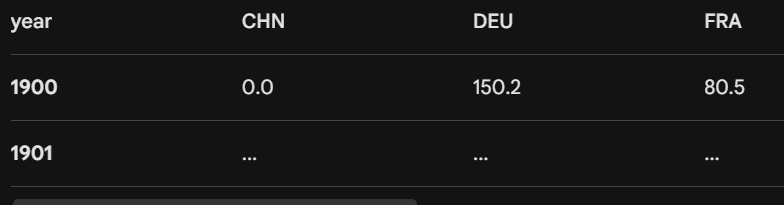

Annexes : Our world in Data. Economics Forum

Exploitation des données :

Chine :

/tmp/ipykernel_206/1988915413.py:35: UserWarning: Glyph 159 (\x9f) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 159 (\x9f) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


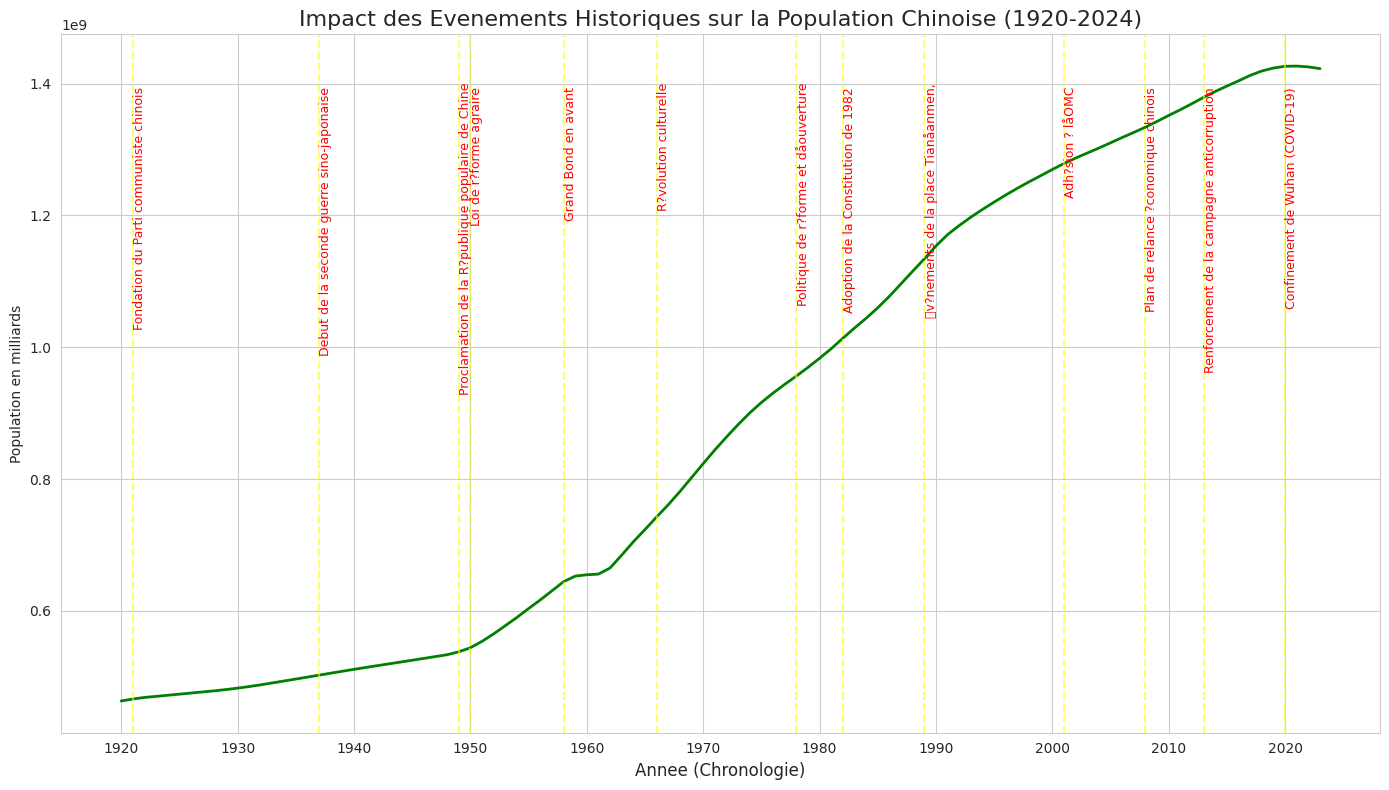

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
url_Donnesnettoyes="https://raw.githubusercontent.com/Tigason509/Projet_Bio_Informatique/refs/heads/main/Donnees_nettoyes"
# Charger le fichier avec l'encodage UTF-8 et le séparateur point-virgule
historical_events_df = pd.read_csv(f"{url_Donnesnettoyes}/Donnees_Chine_Royaume-Uni.csv", encoding='latin1', sep=';')

# Filtrer les donnees pour la Chine a partir de 1920
china_data = panel[(panel['iso3'] == 'CHN') & (panel['year'] >= 1920)].copy()

# Creation d'un seul graphique pour la population
plt.figure(figsize=(14, 8))
plt.title('Impact des Evenements Historiques sur la Population Chinoise (1920-2024)', fontsize=16)

sns.lineplot(x='year', y='population', data=china_data, color='green', linewidth=2)
plt.ylabel('Population en milliards')
plt.xlabel('Annee (Chronologie)', fontsize=12)

# evenements chinois
for index, row in historical_events_df.iterrows():
    if pd.notna(row['date']) and str(row['pays']).strip() == 'Chine':
        try:
            # Extraction de l'annee
            event_year = int(str(row['date']).split('/')[-1])
            event_name = row['Titre']
            if 1920 <= event_year <= 2024:
                plt.axvline(x=event_year, color='yellow', linestyle='--', alpha=0.6)
                # texte
                plt.text(event_year, plt.ylim()[1]*0.95, event_name, rotation=90, color='red', fontsize=9, verticalalignment='top')
        except:
            continue

plt.xticks(range(1920, 2026, 10))
plt.tight_layout()
plt.show()

ensemble des évenements mondiaux en exemple

/tmp/ipykernel_206/3032321748.py:103: UserWarning: Glyph 159 (\x9f) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 0.88, 0.95])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 159 (\x9f) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


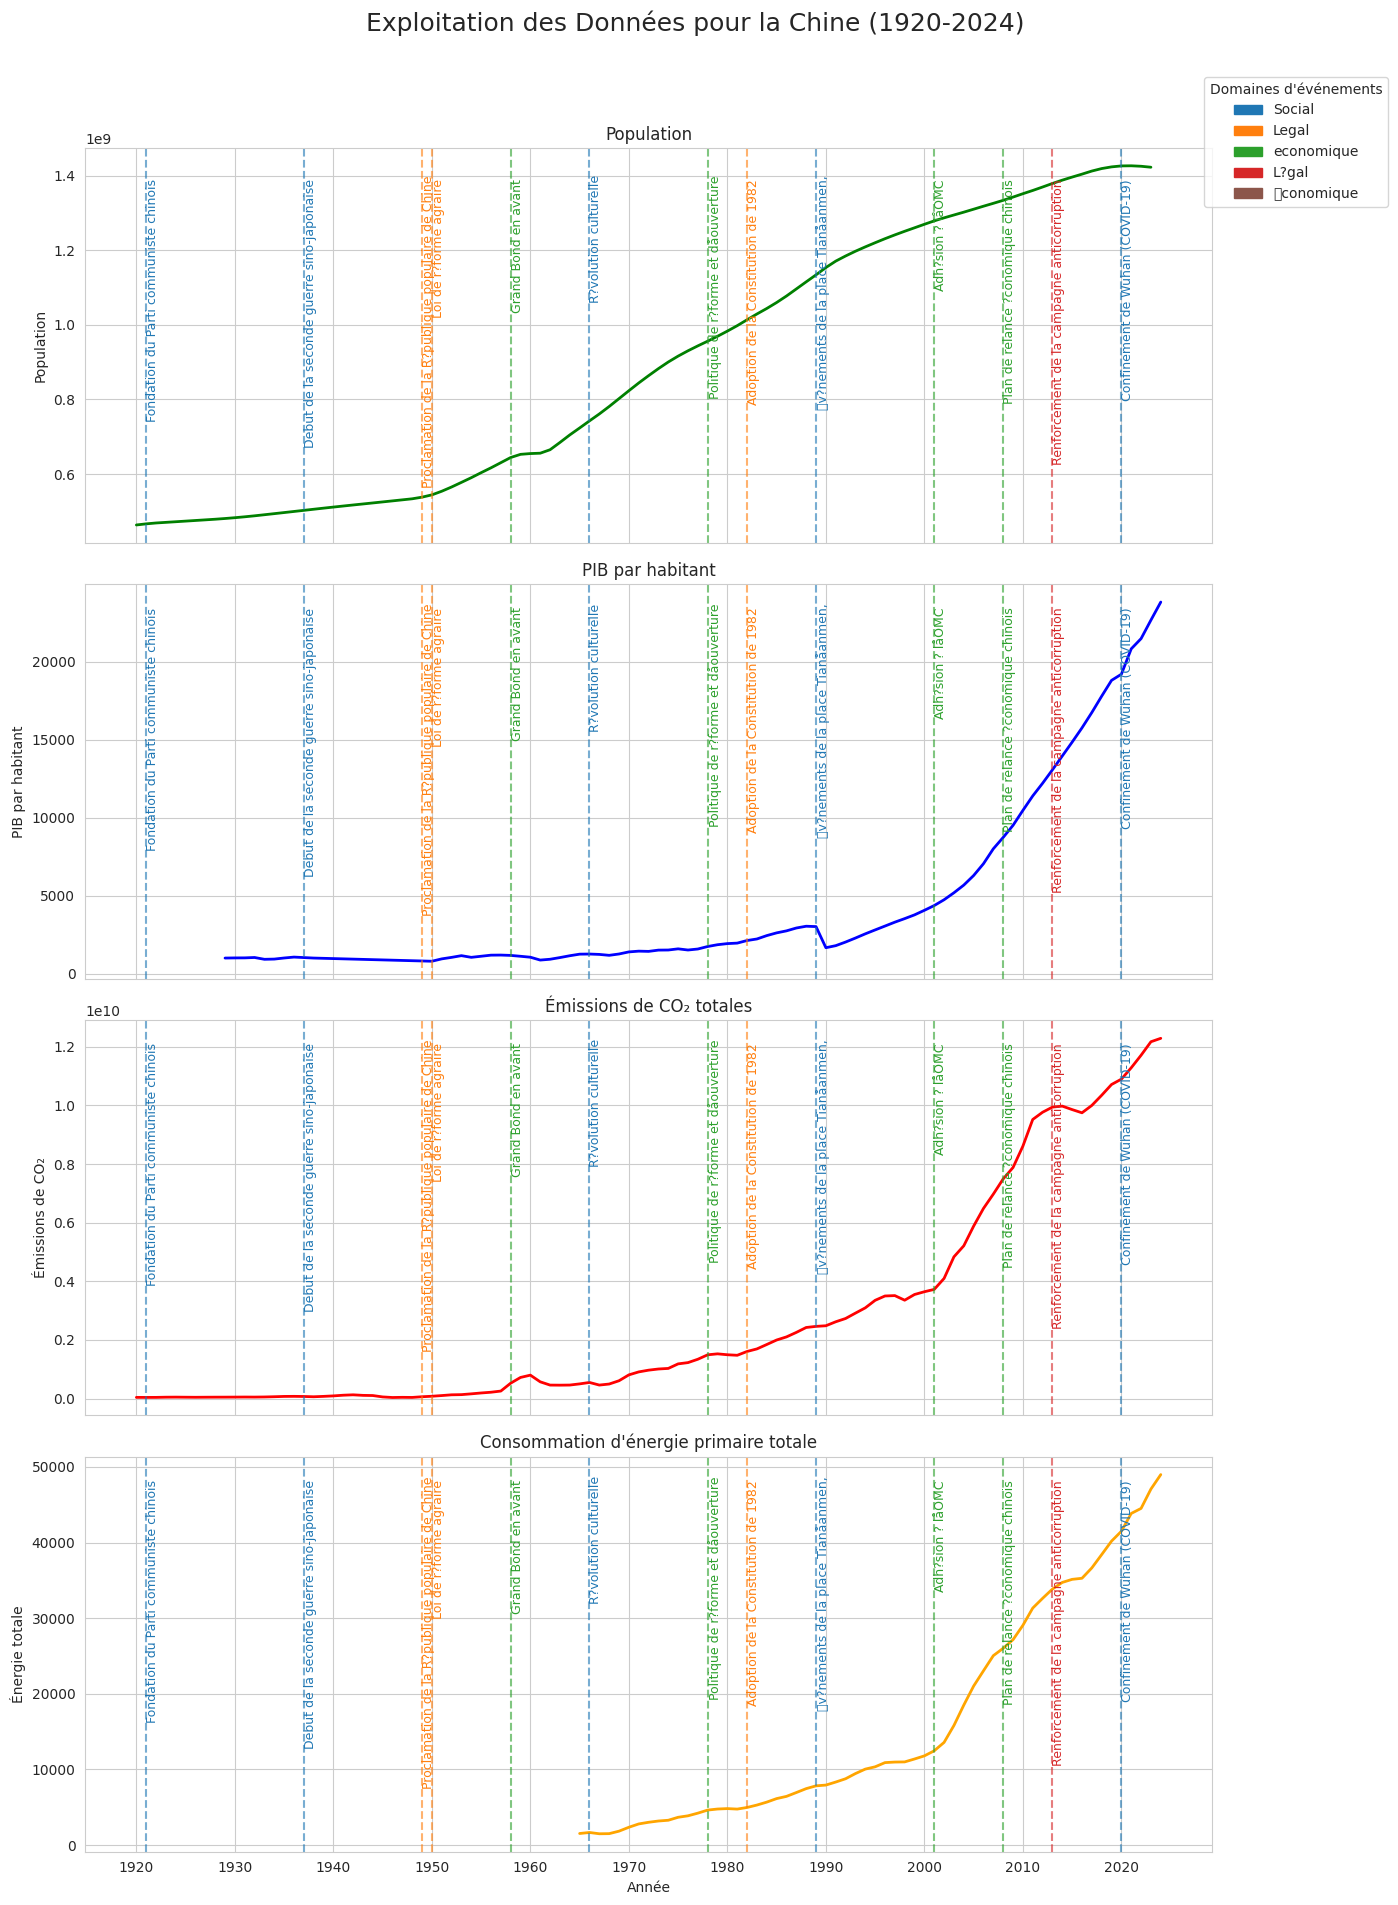

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

sns.set_style("whitegrid")

# Police compatible avec beaucoup de caractères Unicode
plt.rcParams['font.family'] = 'DejaVu Sans'

# Charger les données des événements historiques
evenements_historiques = pd.read_csv(f"{url_Donnesnettoyes}/Donnees_Chine_Royaume-Uni.csv", encoding='latin1', sep=';')
evenements_historiques['domaine'] = evenements_historiques['domaine'].str.strip()
domaines = evenements_historiques['domaine'].unique()
palette_couleurs = sns.color_palette('tab10', len(domaines))
couleur_par_domaine = dict(zip(domaines, palette_couleurs))

# 1. Charger les données (On suppose que 'year' est une colonne grâce au reset_index précédent)
co2_df = pd.read_csv(f"{url_Donnesnettoyes}/co2_pays_cleaned.csv")
pib_df = pd.read_csv(f"{url_Donnesnettoyes}/gdp_pays_cleaned.csv")
pop_df = pd.read_csv(f"{url_Donnesnettoyes}/population_pays_cleaned.csv")
nrj_df = pd.read_csv(f"{url_Donnesnettoyes}/energy_pays_cleaned.csv")

# 2. Créer le DataFrame 'donnees_chine' directement
# On prend la colonne 'year' et la colonne 'CHN' de chaque fichier
donnees_chine = pd.DataFrame()
donnees_chine['year'] = co2_df['year']
donnees_chine['co2_total'] = co2_df['CHN']
donnees_chine['gdp_per_capita'] = pib_df['CHN']
donnees_chine['population'] = pop_df['CHN']

# Pour l'énergie (qui commence en 1965), on fait une fusion car les lignes ne correspondent pas
donnees_chine = pd.merge(donnees_chine, nrj_df[['year', 'CHN']], on='year', how='left')
donnees_chine = donnees_chine.rename(columns={'CHN': 'energy_total'})

# 3. Filtrage final
donnees_chine = donnees_chine[donnees_chine['year'] >= 1920].copy()

# ... le reste de votre code de graphique (plt.subplots, etc.) fonctionnera alors parfaitement !

# Création de la figure avec 4 graphiques
figure, axes = plt.subplots(4, 1, figsize=(14, 20), sharex=True)
figure.suptitle('Exploitation des Données pour la Chine (1920-2024)', fontsize=18, y=0.98)

# Population
sns.lineplot(x='year', y='population', data=donnees_chine, ax=axes[0], color='green', linewidth=2)
axes[0].set_title('Population')
axes[0].set_ylabel('Population')

# PIB par habitant
sns.lineplot(x='year', y='gdp_per_capita', data=donnees_chine, ax=axes[1], color='blue', linewidth=2)
axes[1].set_title('PIB par habitant')
axes[1].set_ylabel('PIB par habitant')

# Émissions CO2
sns.lineplot(x='year', y='co2_total', data=donnees_chine, ax=axes[2], color='red', linewidth=2)
axes[2].set_title('Émissions de CO₂ totales')
axes[2].set_ylabel('Émissions de CO₂')

# Consommation d'énergie
sns.lineplot(x='year', y='energy_total', data=donnees_chine, ax=axes[3], color='orange', linewidth=2)
axes[3].set_title('Consommation d\'énergie primaire totale')
axes[3].set_ylabel('Énergie totale')

# Ajouter les événements historiques des chinois
evenements_chine = evenements_historiques[evenements_historiques['pays'].str.strip() == 'Chine']

for index, ligne in evenements_chine.iterrows():
    if pd.notna(ligne['date']):
        try:
            annee_evenement = int(str(ligne['date']).split('/')[-1])
            nom_evenement = ligne['Titre']
            domaine_evenement = ligne['domaine'].strip()
            couleur_evenement = couleur_par_domaine.get(domaine_evenement, 'gray')

            if 1920 <= annee_evenement <= 2024:
                for ax in axes:
                    ax.axvline(x=annee_evenement, color=couleur_evenement, linestyle='--', alpha=0.6)
                    ax.text(annee_evenement, ax.get_ylim()[1]*0.95, nom_evenement,
                            rotation=90, color=couleur_evenement,
                            fontsize=9, verticalalignment='top')

        except Exception as e:
            print(f"Erreur lors du traitement de l'événement: {ligne['Titre']} - {e}")
            continue

axes[3].set_xlabel('Année')
plt.xticks(range(1920, 2026, 10))

# Création des légendes
elements_legende = [] # Catégories d'evenements légendés

for domaine, couleur in couleur_par_domaine.items():
    if pd.notna(domaine):
        elements_legende.append(mpatches.Patch(color=couleur, label=domaine))

# Ajouter la légende
figure.legend(handles=elements_legende,
              title="Domaines d'événements",
              loc='upper right',
              bbox_to_anchor=(1.0, 0.95))

plt.tight_layout(rect=[0, 0.03, 0.88, 0.95])
plt.show()

Les différents phénomènes j'entends les consomma

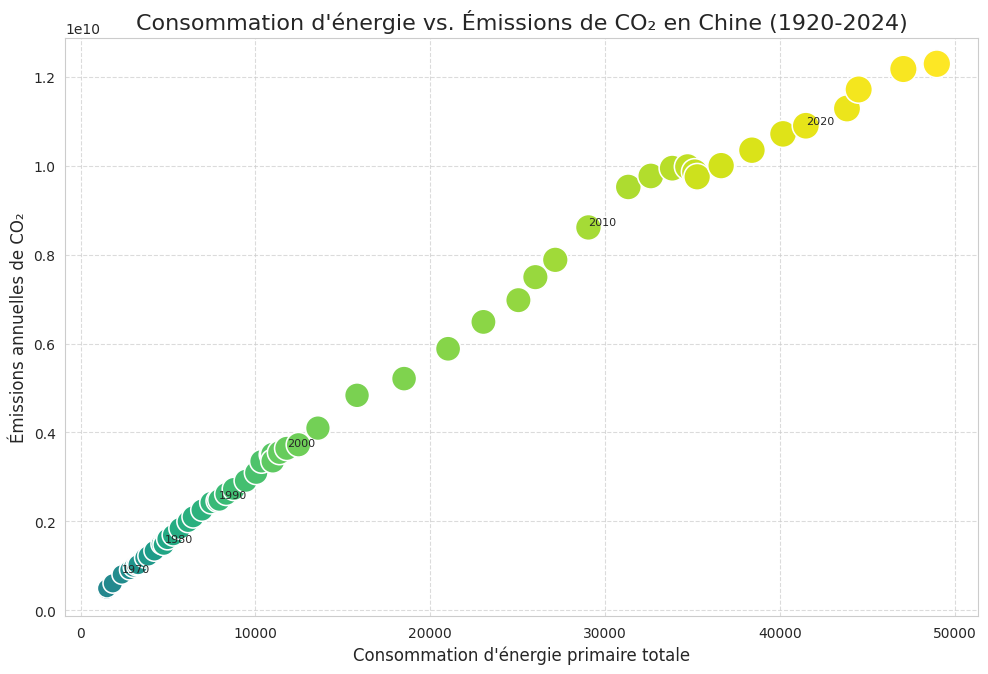

In [36]:
# Créer le graphique croisé
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x='energy_total',
    y='co2_total',
    data=china_data,
    hue='year',
    palette='viridis',
    size='year',
    sizes=(20, 400),
    legend=False
)

plt.title('Consommation d\'énergie vs. Émissions de CO₂ en Chine (1920-2024)', fontsize=16)
plt.xlabel('Consommation d\'énergie primaire totale', fontsize=12)
plt.ylabel('Émissions annuelles de CO₂', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Repère de 10 ans
for i, row in china_data.iterrows():
    if row['year'] % 10 == 0:
        plt.text(row['energy_total'], row['co2_total'], str(int(row['year'])),
                 fontsize=8, ha='left', va='bottom')

plt.tight_layout()
plt.show()

<span style="color: green">
Concernant le graphique que nous venons de générer, il représente la relation entre la consommation d'énergie et les émissions de CO₂ pour la Chine. Ce nuage de points illustre la trajectoire de ces deux indicateurs de 1920 à 2024. Chaque point sur le graphique symbolise une année spécifique, avec sa couleur et sa taille variant en fonction de cette année, ce qui permet de discerner l'évolution temporelle.

Nous constatons une corrélation positive marquée entre la consommation d'énergie et les émissions de CO₂ : l'augmentation de l'une s'accompagne d'une hausse significative de l'autre. Les points se déplacent progressivement du coin inférieur gauche vers le coin supérieur droit, ce qui témoigne d'une croissance simultanée et substantielle des deux variables.

L'utilisation d'une échelle de couleurs et de tailles (allant du violet pour les périodes anciennes au jaune-vert pour les années plus récentes) démontre une augmentation chronologique. Les points correspondant aux premières décennies se situent en bas à gauche, indiquant des niveaux modestes. À l'inverse, les points des années récentes, plus grands et plus clairs, se trouvent en haut à droite, reflétant une augmentation considérable de la consommation d'énergie et des émissions de CO₂. Cela souligne l'intensification de l'industrialisation et du développement économique en Chine sur cette période.

**Exploitation des données pour la france et le royaume Uni**

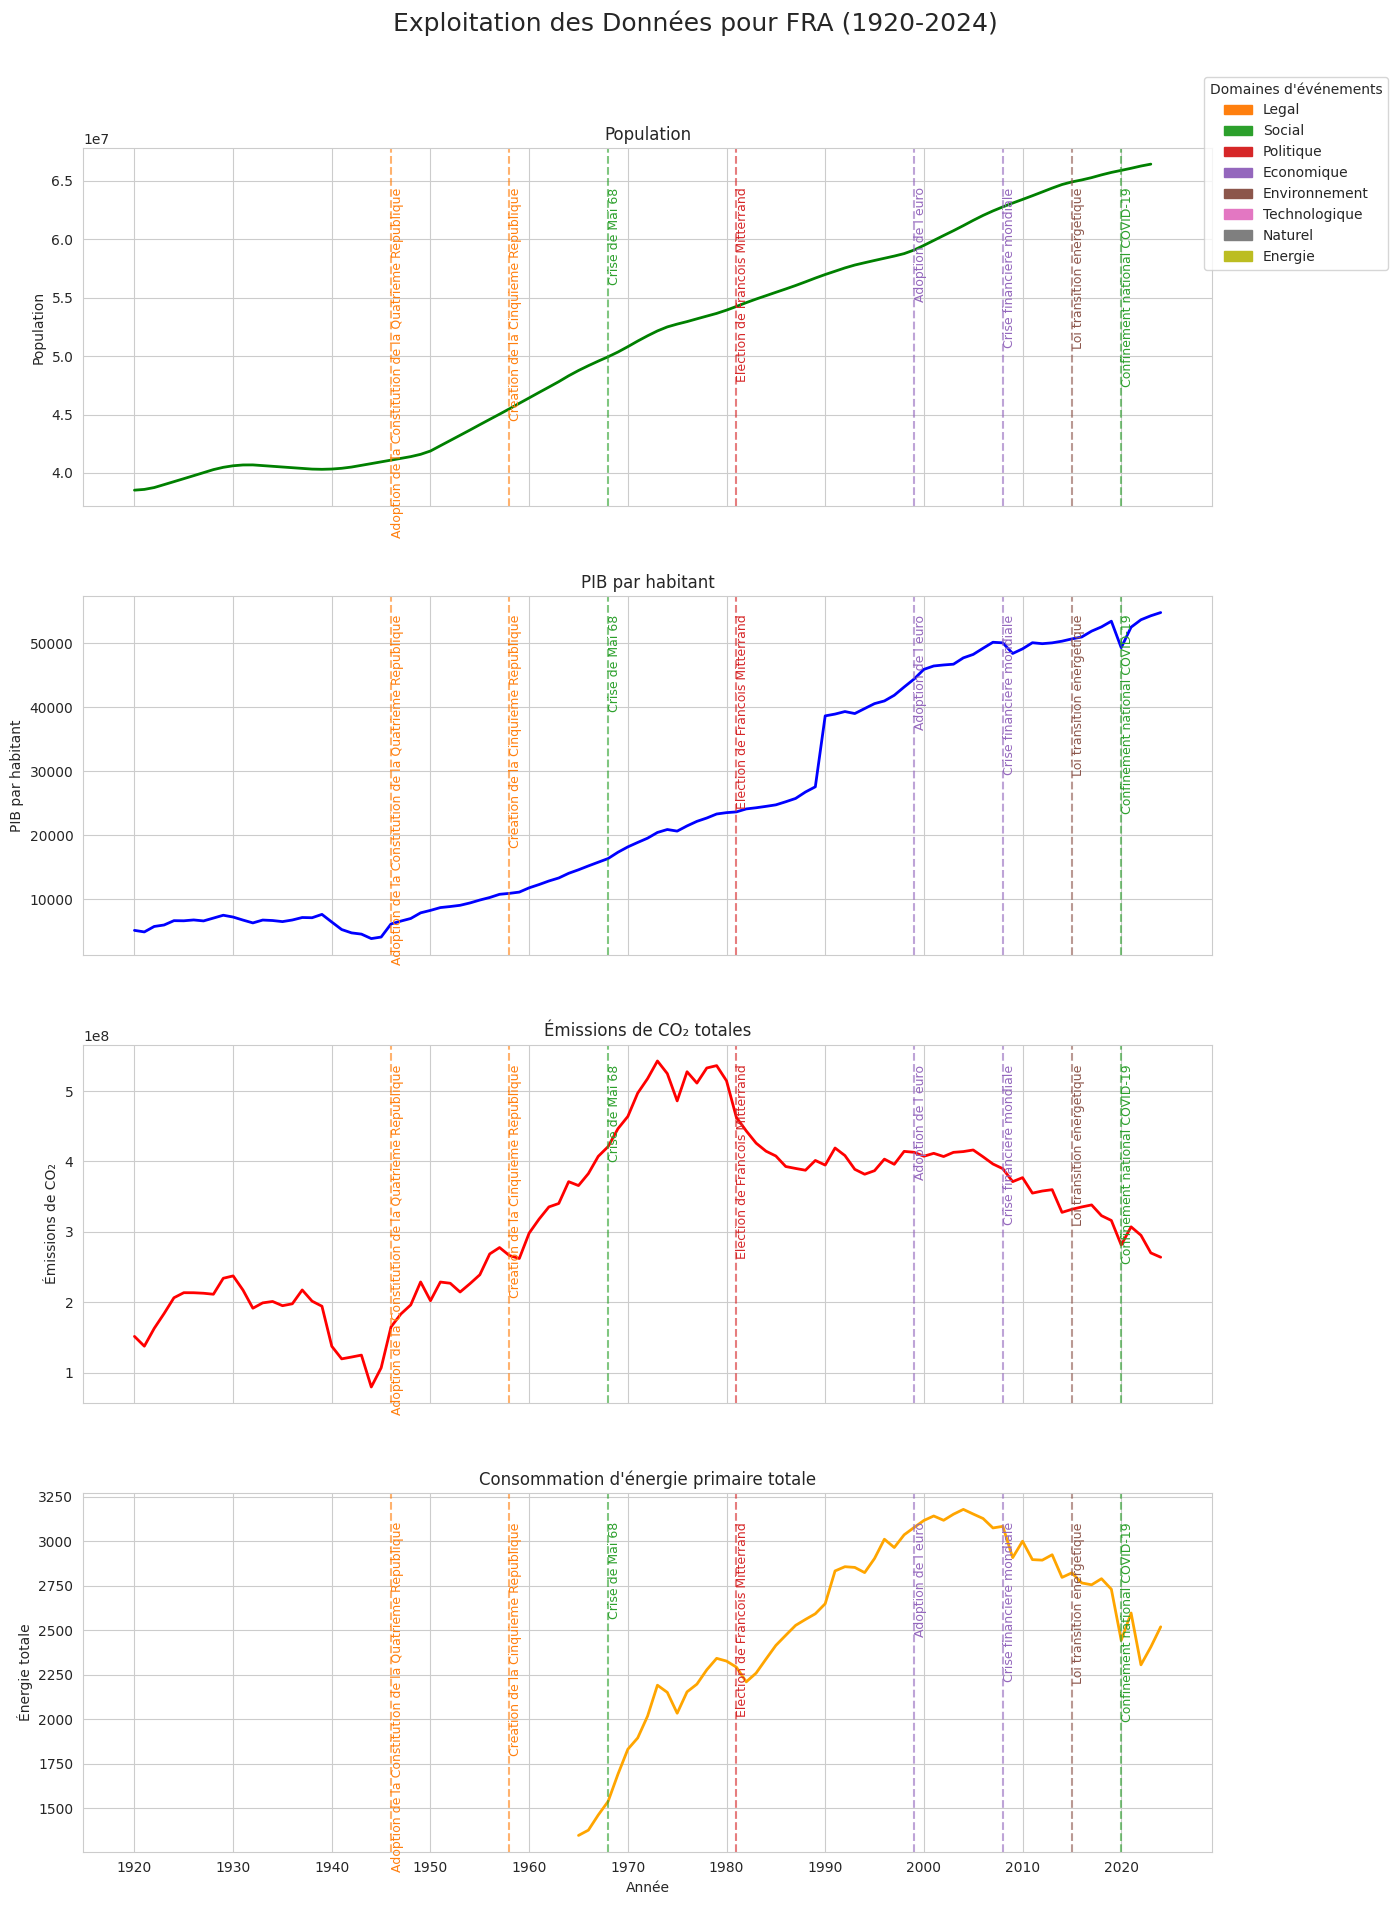

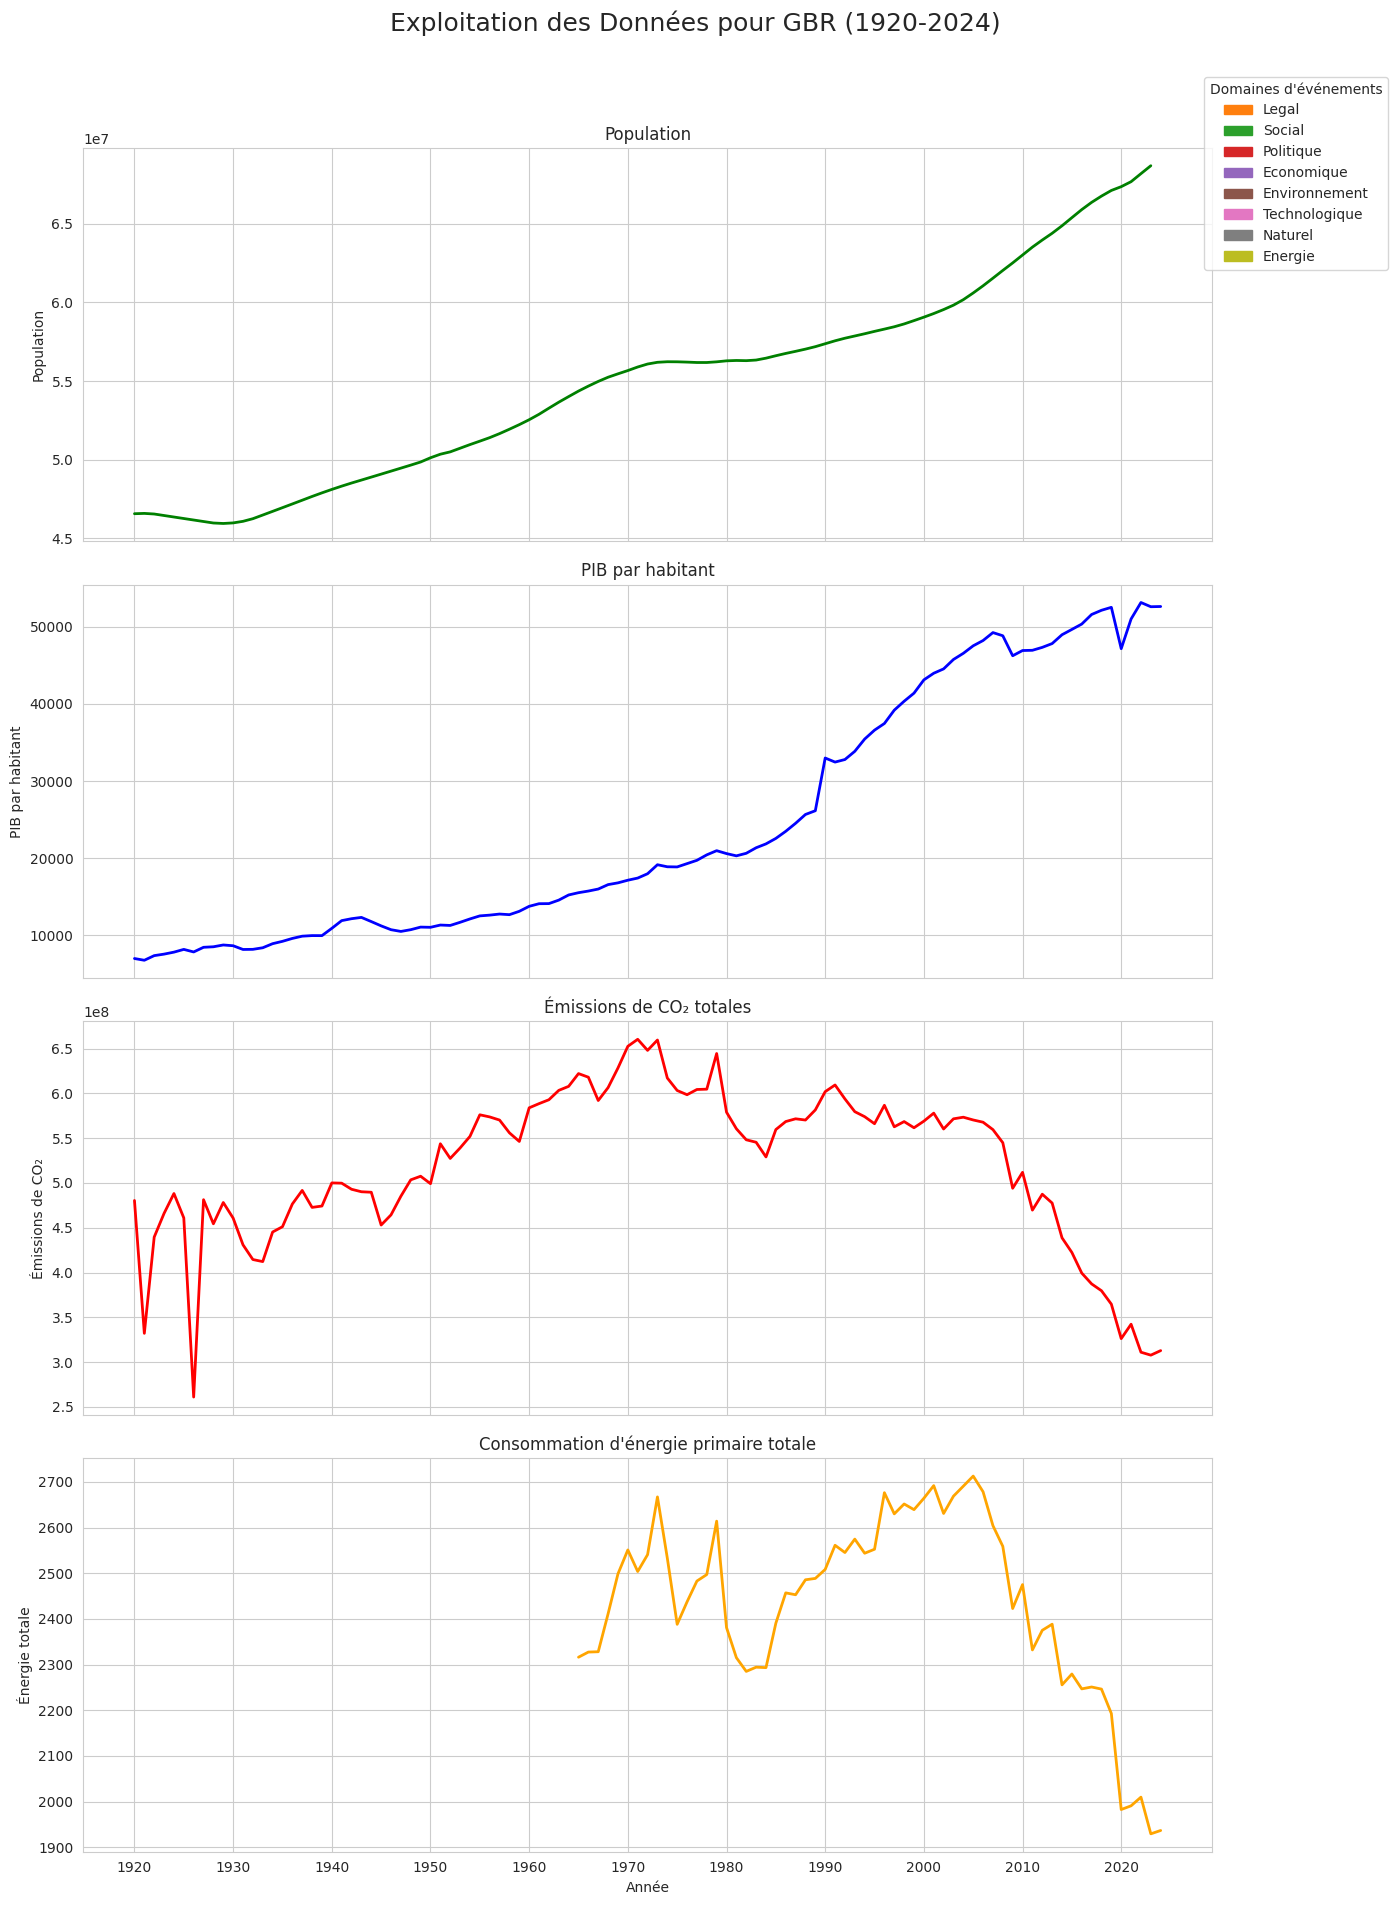

In [37]:
sns.set_style("whitegrid")

# Configuration de la police pour supporter les caractères accentués
plt.rcParams['font.family'] = 'DejaVu Sans'

# Les répertoires (PROJECT_DIR, RAW_DIR, CLEAN_DIR) sont déjà définis globalement

# --- Chargement et préparation des données ---

# Charger les données des événements historiques depuis le nouveau fichier (maintenant dans CLEAN_DIR)
evenements_historiques_df = pd.read_csv(f"{url_Donnesnettoyes}/bioinfo_dataset.csv", encoding='latin1', sep=';')

# Créer une palette de couleurs pour les différents domaines d'événements
domaines_tous = evenements_historiques_df['domaine'].str.strip().unique()
palette_couleurs = sns.color_palette('tab10', len(domaines_tous))
carte_couleur_domaine = dict(zip(domaines_tous, palette_couleurs))

# --- Génération des graphiques pour les pays cibles ---

pays_cibles = ["FRA", "GBR"]

for code_pays in pays_cibles:

    donnees_pays = panel[(panel['iso3'] == code_pays) & (panel['year'] >= 1920)].copy()

    # Création de la figure et des axes pour les sous-graphiques
    figure, axes = plt.subplots(4, 1, figsize=(14, 20), sharex=True)
    figure.suptitle(f'Exploitation des Données pour {code_pays} (1920-2024)', fontsize=18, y=0.98)

    # Population
    sns.lineplot(x='year', y='population', data=donnees_pays, ax=axes[0], color='green', linewidth=2)
    axes[0].set_title('Population')
    axes[0].set_ylabel('Population')

    # PIB par habitant
    sns.lineplot(x='year', y='gdp_per_capita', data=donnees_pays, ax=axes[1], color='blue', linewidth=2)
    axes[1].set_title('PIB par habitant')
    axes[1].set_ylabel('PIB par habitant')

    # Émissions CO2
    sns.lineplot(x='year', y='co2_total', data=donnees_pays, ax=axes[2], color='red', linewidth=2)
    axes[2].set_title('Émissions de CO₂ totales')
    axes[2].set_ylabel('Émissions de CO₂')

    # Consommation d'énergie
    sns.lineplot(x='year', y='energy_total', data=donnees_pays, ax=axes[3], color='orange', linewidth=2)
    axes[3].set_title("Consommation d'énergie primaire totale")
    axes[3].set_ylabel('Énergie totale')

    # Filtrer les événements historiques pour le pays actuel
    evenements_pays = evenements_historiques_df[
        evenements_historiques_df['pays'].str.strip() ==
        ('France' if code_pays == 'FRA' else 'Royaume-Uni')
    ]

    # Ajouter les événements historiques aux graphiques
    for indice, ligne_evenement in evenements_pays.iterrows():

        if pd.notna(ligne_evenement['date']):
            try:
                annee_evenement = int(str(ligne_evenement['date']).split('/')[-1])
                nom_evenement = ligne_evenement['titre'] # Corrigé de 'Titre' à 'titre'
                domaine_evenement = ligne_evenement['domaine'].strip()
                couleur_evenement = carte_couleur_domaine.get(domaine_evenement, 'gray')

                if 1920 <= annee_evenement <= 2024:

                    for ax in axes:
                        ax.axvline(x=annee_evenement, color=couleur_evenement, linestyle='--', alpha=0.6)
                        ax.text(
                            annee_evenement,
                            ax.get_ylim()[1]*0.95,
                            nom_evenement,
                            rotation=90,
                            color=couleur_evenement,
                            fontsize=9,
                            verticalalignment='top'
                        )

            except Exception as erreur:
                print(f"Erreur lors du traitement de l'événement: {ligne_evenement['titre']} pour {code_pays} - {erreur}")
                continue

    axes[3].set_xlabel('Année')
    plt.xticks(range(1920, 2026, 10))

    # Création des éléments de légende pour les domaines d'événements
    elements_legende = []

    for domaine, couleur in carte_couleur_domaine.items():
        if pd.notna(domaine):
            elements_legende.append(mpatches.Patch(color=couleur, label=domaine))

    # Ajouter la légende à la figure
    figure.legend(
        handles=elements_legende,
        title="Domaines d'événements",
        loc='upper right',
        bbox_to_anchor=(1.0, 0.95)
    )

    plt.tight_layout(rect=[0, 0.03, 0.88, 0.95])
    plt.show()

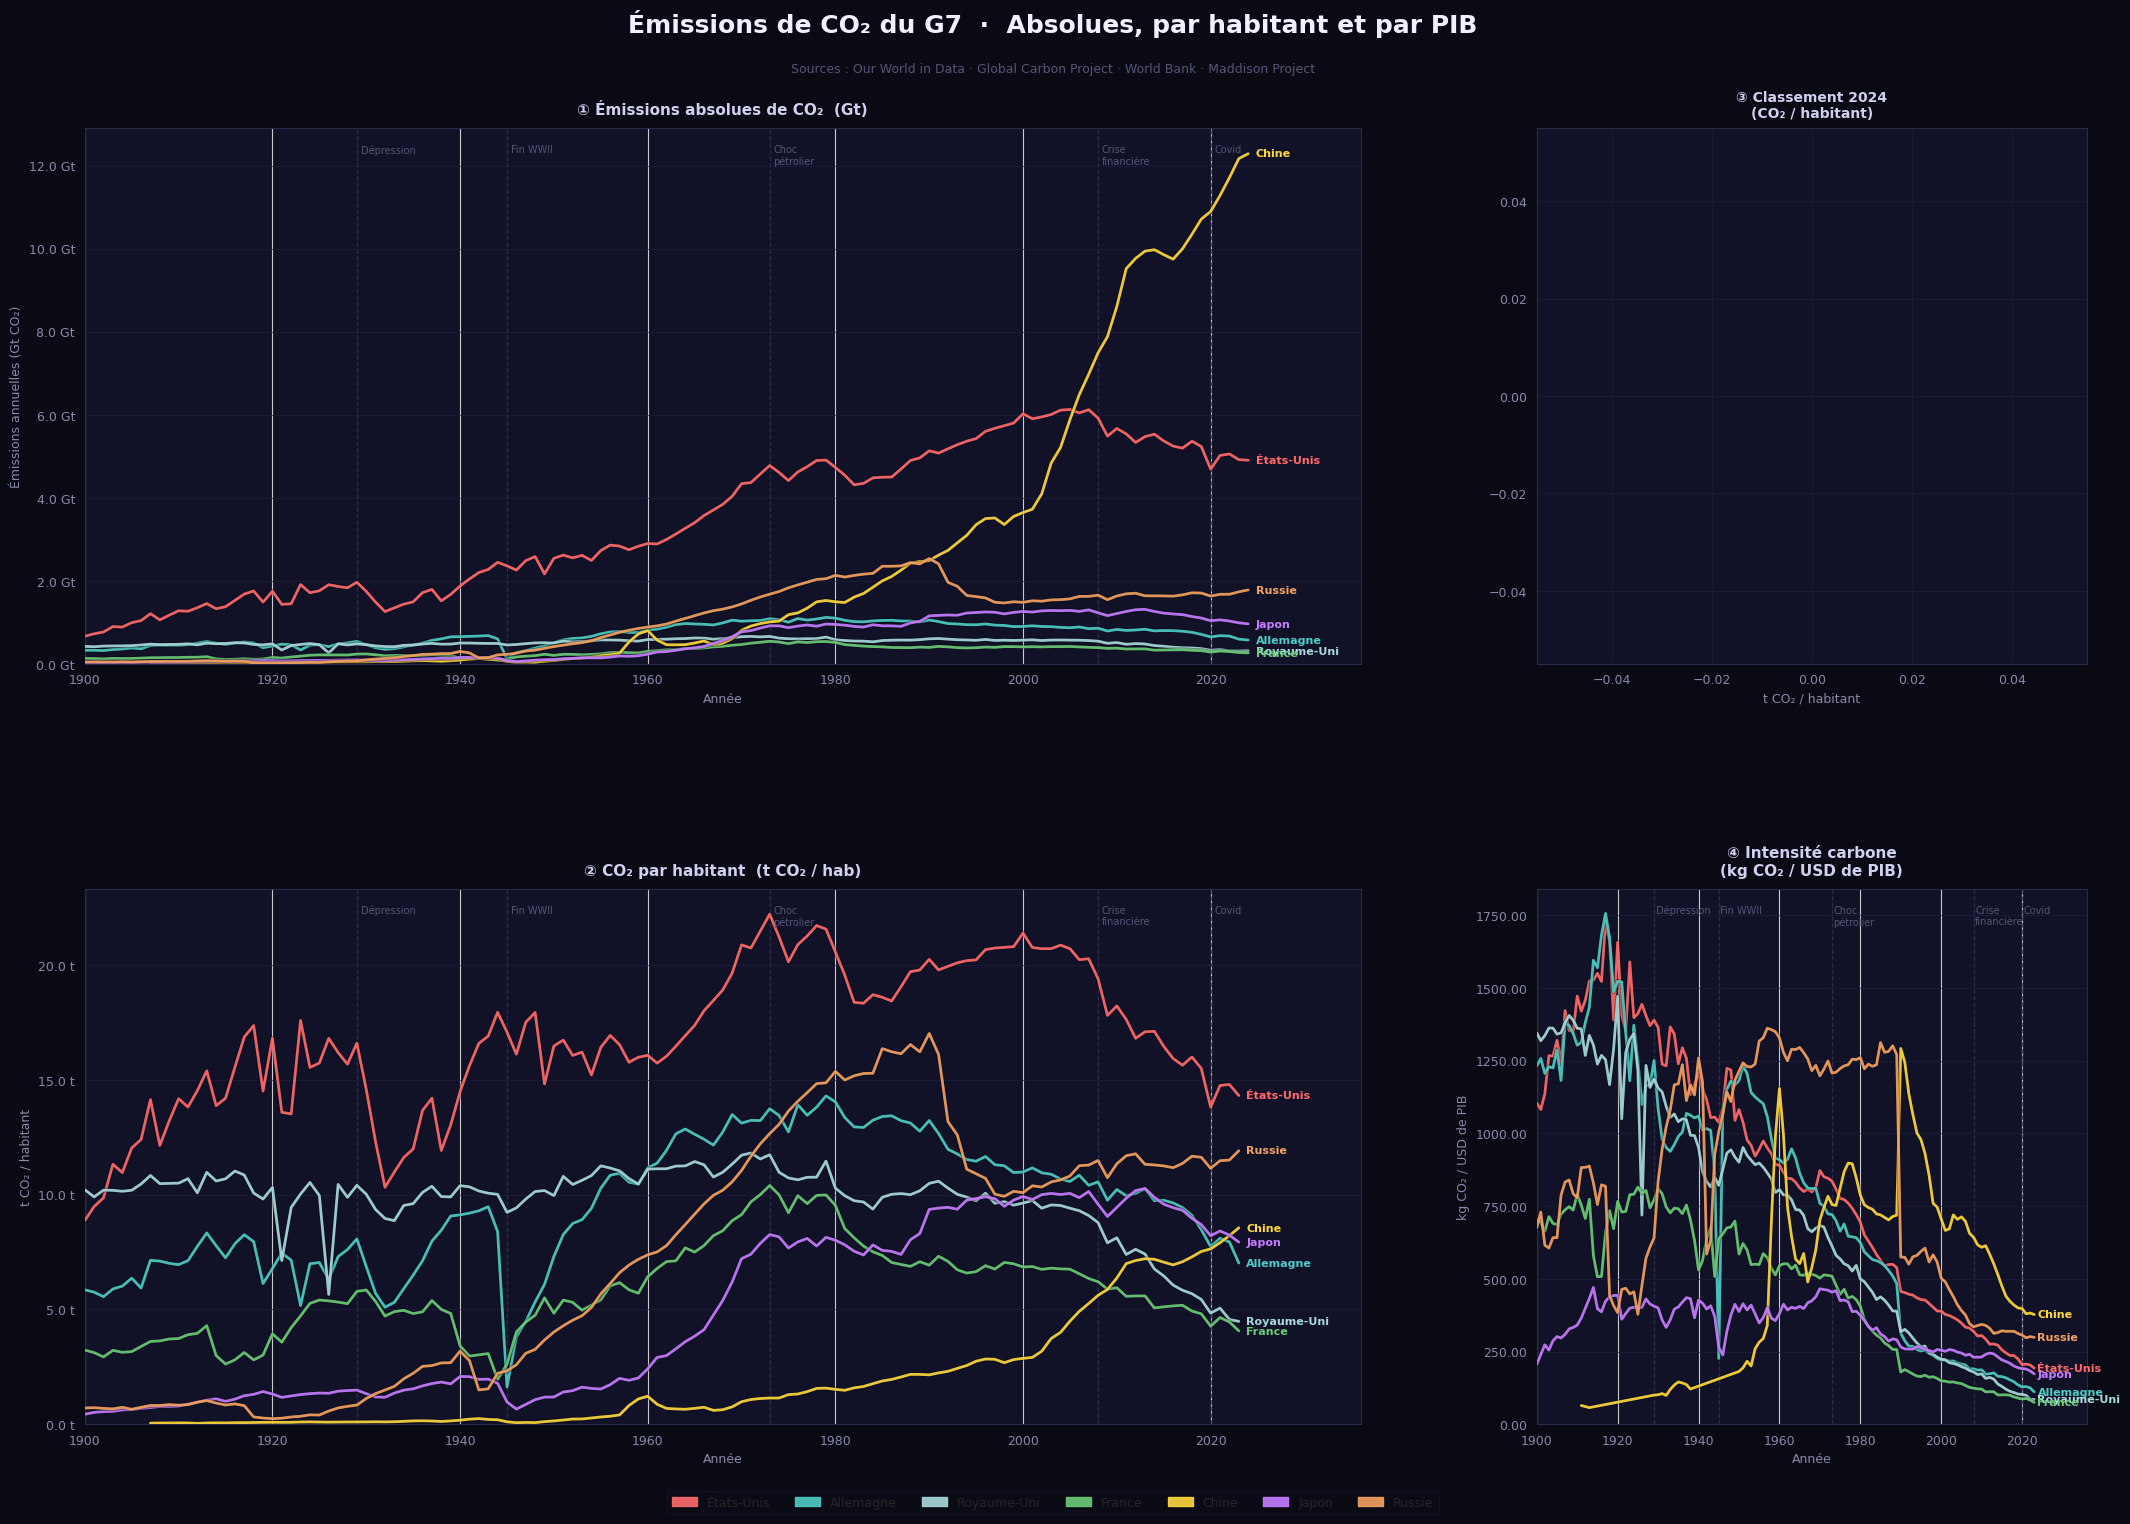

In [38]:
import warnings
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.gridspec as GridSpec
import matplotlib.ticker as FuncFormatter
import matplotlib.patheffects as pe


warnings.filterwarnings('ignore')

# Mise à jour des codes et noms des pays
G7_CODES = ['USA', 'DEU', 'GBR', 'FRA', 'CHN', 'JPN', 'RUS'] # Remplacement de ITA et CAN par CHN et RUS
G7_NOMS  = {
    'USA': 'États-Unis',
    'DEU': 'Allemagne',
    'GBR': 'Royaume-Uni',
    'FRA': 'France',
    'CHN': 'Chine',
    'JPN': 'Japon',
    'RUS': 'Russie',
}
COULEURS = {
    'USA': '#FF6B6B',
    'DEU': '#4ECDC4',
    'GBR': '#A8DADC',
    'FRA': '#6BCB77',
    'CHN': '#FFD93D',
    'JPN': '#C77DFF',
    'RUS': '#F4A261',
}

BG    = '#0a0a14'
PANEL = '#111128'
ANNEE_DEBUT = 1900


# Renommer les colonnes pour correspondre au format attendu par le reste du code
# Le code G7_CODES utilise 'code' au lieu de 'iso3'
co2_clean = co2_clean.rename(columns={'iso3': 'code', 'co2_total': 'co2'})
pop_clean = pop_clean.rename(columns={'iso3': 'code', 'population': 'population'})
gdp_clean = gdp_clean.rename(columns={'iso3': 'code', 'gdp_per_capita': 'gdp'})

# Filtrer uniquement les pays du G7_CODES après chargement et renommage
co2 = co2_clean[co2_clean['code'].isin(G7_CODES)]
pop = pop_clean[pop_clean['code'].isin(G7_CODES)]
gdp = gdp_clean[gdp_clean['code'].isin(G7_CODES)]

# ── Fusion globale ────────────────────────────────────────────────
panel = (co2
         .merge(pop, on=['code', 'year'], how='left')
         .merge(gdp, on=['code', 'year'], how='left'))

panel = panel[panel['year'] >= ANNEE_DEBUT].copy()

# ── Indicateurs normalisés ────────────────────────────────────────
panel['co2_per_capita'] = (panel['co2'] / panel['population'])          # t CO2 / habitant
panel['co2_per_gdp']    = (panel['co2'] / (panel['gdp'] * panel['population'])) * 1e6  # kg CO2 / USD de PIB

# ─────────────────────────────────────────────────────────────────
# FIGURE
# ─────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(22, 16), facecolor=BG)
gs  = GridSpec.GridSpec(2, 3, figure=fig,
               hspace=0.42, wspace=0.32,
               left=0.06, right=0.97,
               top=0.88, bottom=0.07)

ax_abs    = fig.add_subplot(gs[0, :2])   # CO2 absolu — large
ax_cap    = fig.add_subplot(gs[1, :2])   # CO2 / habitant — large
ax_bar23  = fig.add_subplot(gs[0, 2])    # barres 2023 — par habitant
ax_gdp    = fig.add_subplot(gs[1, 2])    # CO2 / PIB

AXES = [ax_abs, ax_cap, ax_bar23, ax_gdp]
for ax in AXES:
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a4a')
        spine.set_linewidth(0.8)
    ax.tick_params(colors='#8888aa', labelsize=9)
    ax.xaxis.label.set_color('#8888aa')
    ax.yaxis.label.set_color('#8888aa')
    ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

EVENTS = [
    (1929, 'Dépression'),
    (1945, 'Fin WWII'),
    (1973, 'Choc\npétrolier'),
    (2008, 'Crise\nfinancière'),
    (2020, 'Covid'),
]

def tracer_courbes(ax, col, ylabel, title, fmt_y=None, annot_offset_pct=0.97):
    for code in G7_CODES:
        d = panel[panel['code'] == code].dropna(subset=[col])
        if d.empty:
            continue
        line, = ax.plot(d['year'], d[col],
                        color=COULEURS[code], linewidth=2.0, alpha=0.92, zorder=3)
        line.set_path_effects([
            pe.Stroke(linewidth=3.5, foreground=BG, alpha=0.35),
            pe.Normal()
        ])
        # Label dernier point
        last = d.iloc[-1]
        ax.text(last['year'] + 0.8, last[col],
                f'{G7_NOMS[code]}',
                color=COULEURS[code], fontsize=8, va='center', fontweight='bold')

    # Événements
    ymin, ymax = ax.get_ylim()
    for yr, label in EVENTS:
        ax.axvline(yr, color='#333355', linewidth=0.9, linestyle='--', alpha=0.8, zorder=1)
        ax.text(yr + 0.4, ymax * annot_offset_pct,
                label, color='#555577', fontsize=7, va='top')

    ax.set_xlim(ANNEE_DEBUT, panel['year'].max() + 12)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Année', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, color='#d0d0f0', fontsize=11, fontweight='bold', pad=10)
    if fmt_y:
        ax.yaxis.set_major_formatter(FuncFormatter.FuncFormatter(fmt_y))

# ── Graphe 1 : CO2 absolu (Gt) ───────────────────────────────────
tracer_courbes(
    ax_abs, 'co2',
    'Émissions annuelles (Gt CO₂)',
    '① Émissions absolues de CO₂  (Gt)',
    fmt_y=lambda x, _: f'{x/1e9:.1f} Gt'
)

# ── Graphe 2 : CO2 / habitant (t)
tracer_courbes(
    ax_cap, 'co2_per_capita',
    't CO₂ / habitant',
    '② CO₂ par habitant  (t CO₂ / hab)',
    fmt_y=lambda x, _: f'{x:.1f} t'
)

# Graphe 3 : Barres comparatives 2022 — CO2/hab
annee_ref = panel['year'].max()
snap = (panel[panel['year'] == annee_ref]
        .set_index('code')['co2_per_capita']
        .reindex(G7_CODES)
        .dropna()
        .sort_values(ascending=True))

bars = ax_bar23.barh(
    [G7_NOMS[c] for c in snap.index],
    snap.values,
    color=[COULEURS[c] for c in snap.index],
    height=0.6, alpha=0.88, zorder=3
)
for bar, val in zip(bars, snap.values):
    ax_bar23.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                  f'{val:.1f} t', va='center', fontsize=8, color='#ccccee')

ax_bar23.set_xlabel('t CO₂ / habitant', fontsize=9)
ax_bar23.set_title(f'③ Classement {int(annee_ref)}\n(CO₂ / habitant)',
                   color='#d0d0f0', fontsize=10, fontweight='bold', pad=8)
ax_bar23.xaxis.grid(True, color='#1e1e3a', linewidth=0.5)
ax_bar23.set_axisbelow(True)

# Graphe 4 : CO2 / PIB (intensité carbone)
tracer_courbes(
    ax_gdp, 'co2_per_gdp',
    'kg CO₂ / USD de PIB',
    '④ Intensité carbone\n(kg CO₂ / USD de PIB)',
    fmt_y=lambda x, _: f'{x:.2f}'
)

# Titre
fig.text(0.5, 0.94,
         'Émissions de CO₂ du G7  ·  Absolues, par habitant et par PIB',
         ha='center', fontsize=18, fontweight='bold', color='#f0f0ff')
fig.text(0.5, 0.915,
         'Sources : Our World in Data · Global Carbon Project · World Bank · Maddison Project',
         ha='center', fontsize=9, color='#555577')

handles = [mpatches.Patch(color=COULEURS[c], label=G7_NOMS[c], alpha=0.9)
           for c in G7_CODES]
fig.legend(handles=handles,
           loc='lower center', ncol=7,
           fontsize=9, framealpha=0.15,
           facecolor=PANEL, edgecolor='#333355',
           bbox_to_anchor=(0.5, 0.01))


plt.savefig('g7_co2_normalise.png', dpi=160,
            bbox_inches='tight', facecolor=BG)
plt.show()

<span style="color: green">
La Chine  explose littéralement depuis les années 2000, dépassant 12 Gt et écrasant tous les autres pays. Les États-Unis plafonnent autour de 5–6 Gt depuis les années 70 puis amorcent une légère baisse. Tous les pays européens + Japon + Russie restent groupés en bas du graphe, quasi invisibles à cette échelle.

Cependant pour le CO2 par habitant,
le classement s'inverse radicalement. Les États-Unis dominent largement (~20 t/hab au pic), suivis par la Russie. La Chine ne dépasse que récemment les pays européens. La France et le Royaume-Uni sont en bas du classement — signe d'une économie décarbonée relativement tôt. On voit clairement l'effet des deux guerres mondiales et du choc pétrolier de 1973 sur toutes les courbes.


Concernant l'intensité carbone.
Les valeurs atteignent des niveaux aberrants (~1500+) en début de période, ce qui confirme le même problème d'unités sur le PIB. La tendance générale à la baisse est réelle mais les échelles sont faussées.

Essayons d'isoler une tendance sur la nature des choix politiques

Nous allons d'abord identifier directement sur la courbe les periodes de récession

In [57]:



if 'variables_evenementshistoriques' not in globals():
    try:
        variables_evenementshistoriques = pd.read_csv(f"{url_Donnesnettoyes}/bioinfo_dataset.csv", encoding='latin1', sep=';')
    except FileNotFoundError:
        print("Le fichier 'bioinfo_dataset.csv' n'a pas été trouvé dans CLEAN_DIR.")
        variables_evenementshistoriques = pd.DataFrame(columns=['date', 'pays', 'domaine', 'Titre'])

# Correction de la casse si la variable existe déjà avec 'titre'
if 'titre' in variables_evenementshistoriques.columns:
    variables_evenementshistoriques = variables_evenementshistoriques.rename(columns={'titre': 'Titre'})

pays = ['USA', 'DEU', 'GBR', 'FRA', 'CHN', 'JPN', 'RUS']
evenements_chuteCO2 = []

for iso3 in pays:
    country_data = panel[panel['code'] == iso3].copy()
    country_data = country_data.sort_values('year')
    country_data['co2_diff'] = country_data['co2'].diff()
    chute_CO2 = country_data[country_data['co2_diff'] < 0]['year'].tolist()

    nom_pays = ''
    if iso3 == 'USA': nom_pays = 'Etats-Unis'
    elif iso3 == 'DEU': nom_pays = 'Allemagne'
    elif iso3 == 'GBR': nom_pays = 'Royaume-Uni'
    elif iso3 == 'FRA': nom_pays = 'France'
    elif iso3 == 'CHN': nom_pays = 'Chine'
    elif iso3 == 'JPN': nom_pays = 'Japon'
    elif iso3 == 'RUS': nom_pays = 'Russie'

    if nom_pays:
        events_for_country = variables_evenementshistoriques[variables_evenementshistoriques['pays'].str.strip() == nom_pays]
        for annee_baisse in chute_CO2:
            evenements_lies = events_for_country[
                (events_for_country['date'].astype(str).str.contains(str(annee_baisse)) |
                 events_for_country['date'].astype(str).str.contains(str(annee_baisse - 1)) |
                 events_for_country['date'].astype(str).str.contains(str(annee_baisse + 1)))
            ].copy()

            for _, event_row in evenements_lies.iterrows():
                domaine_lies = event_row['domaine'].strip() if pd.notna(event_row['domaine']) else 'Inconnu'
                evenements_chuteCO2.append({
                    'country': iso3,
                    'year_co2_decrease': annee_baisse,
                    'event_domain': domaine_lies,
                    'event_title': event_row['Titre']
                })

df_eve_chute_CO2 = pd.DataFrame(evenements_chuteCO2)
if not df_eve_chute_CO2.empty:
    print("Domaines d'événements associés aux baisses de CO2 (par fréquence) :")
    print(df_eve_chute_CO2['event_domain'].value_counts())
    print("\nQuelques exemples d'événements associés aux baisses de CO2 :")
    for domain in df_eve_chute_CO2['event_domain'].unique():
        print(f"\nDomaine : {domain}")
        print(df_eve_chute_CO2[df_eve_chute_CO2['event_domain'] == domain].head(3).to_string(index=False))
else:
    print("Aucun événement pertinent n'a été trouvé pour les périodes de baisse du CO2.")

Domaines d'événements associés aux baisses de CO2 (par fréquence) :
event_domain
Economique       20
Politique        20
Social           13
Legal             4
Environnement     3
Naturel           2
Energie           2
Name: count, dtype: int64

Quelques exemples d'événements associés aux baisses de CO2 :

Domaine : Economique
country  year_co2_decrease event_domain                   event_title
    USA               1928   Economique Krach boursier de Wall Street
    USA               1930   Economique Krach boursier de Wall Street
    USA               1945   Economique      Accords de Bretton Woods

Domaine : Social
country  year_co2_decrease event_domain                event_title
    USA               2001       Social  Attentats du 11 septembre
    USA               2019       Social Urgence nationale COVID-19
    USA               2020       Social Urgence nationale COVID-19

Domaine : Environnement
country  year_co2_decrease  event_domain                event_title
    USA   

In [59]:
col_iso_original = terres_arables.columns[1]
col_year_original = terres_arables.columns[2]
col_data_original = terres_arables.columns[3]

terres_arables = terres_arables.rename(columns={
    col_iso_original: 'iso3',
    col_year_original: 'year',
    col_data_original: 'terres_arables'
})

terres_arables_nettoye = terres_arables[['iso3', 'year', 'terres_arables']].copy()

terres_arables_nettoye['iso3'] = terres_arables_nettoye['iso3'].str.strip()
terres_arables_7 = terres_arables_nettoye[terres_arables_nettoye["iso3"].isin(TARGET)].copy()

ta_l = terres_arables_7.pivot(index='year', columns='iso3', values='terres_arables')
ta_l = ta_l.loc[1920:]
ta_l.to_csv("terres_arables_nettoyes.csv", index=True)

print(" Succès ! Fichier créé.")
display(ta_l.head())

✅ Succès ! Fichier créé.


iso3,CHN,DEU,FRA,GBR,JPN,RUS,USA
year,,,,,,,
1920,326052350.0,26018484.0,37910670.0,17541288.0,4667193.0,187575200.0,340558530.0
1930,322786620.0,26175792.0,37686136.0,18056520.0,5266174.0,206352580.0,370053400.0
1940,316815840.0,26392618.0,35941096.0,18512432.0,5982154.0,245838980.0,403366270.0
1950,311769730.0,25809198.0,34953830.0,19290580.0,6625146.0,178946460.0,437786880.0
1951,316649860.0,25706824.0,34886332.0,19299440.0,6720602.0,182289900.0,438932160.0
